# Análisis Exploratorio de Datos

## 1. Importación de librerías y carga de datos.

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings

# Configuración de warnings y pandas.
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Estilo global de gráficos.
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print(f'Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [3]:
ruta = './data/GAP_clean.csv'
df = pd.read_csv(ruta)
print(f'Dataset cargado correctamente!')
print(f'Numero de filas: {df.shape[0]} | Numero de columnas: {df.shape[1]}')
df.head()

Dataset cargado correctamente!
Numero de filas: 8000 | Numero de columnas: 16


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades,risk_flag,gaming_intensity
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.46,0,Extremo (6-8h)
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.23,0,Minimo (0-1h)
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.56,0,Moderado (1-3h)
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.67,1,Extremo (6-8h)
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.71,0,Intenso (3-6h)


Al cargar de nuevo el dataset, se convierte en tipo object. Por tanto, hay que restaurar los tipos de nuevo.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
 14  risk_flag         8000 non-null   int64  
 15  gaming_intensity  8000 non-null   object 
dtypes: float64(9), int64(3), object(4)
memory 

In [5]:
# Restaurar el tipo ordinal de stress_level tras la carga.
stress_order = pd.CategoricalDtype(categories=['Low', 'Medium', 'High'], ordered=True)
df['stress_level'] = df['stress_level'].astype(stress_order)

# Restaurar gaming_intensity como categoría ordenada.
intensity_order = pd.CategoricalDtype(
    categories=['Minimo (0-1h)', 'Moderado (1-3h)','Intenso (3-6h)','Extremo (6-8h)'], 
    ordered=True
)
df['gaming_intensity'] = df['gaming_intensity'].astype(intensity_order)

print(f'Cambios realizados correctamente!')


Cambios realizados correctamente!


## 2. Distribuciones univariadas

El objetivo es entender cada variable por separado antes de cruzarlas, de esta forma obtenemos más información sobre la naturaleza real de los datos.

Comenzaremos por investigar la distribución de las variables numéricas continuas.

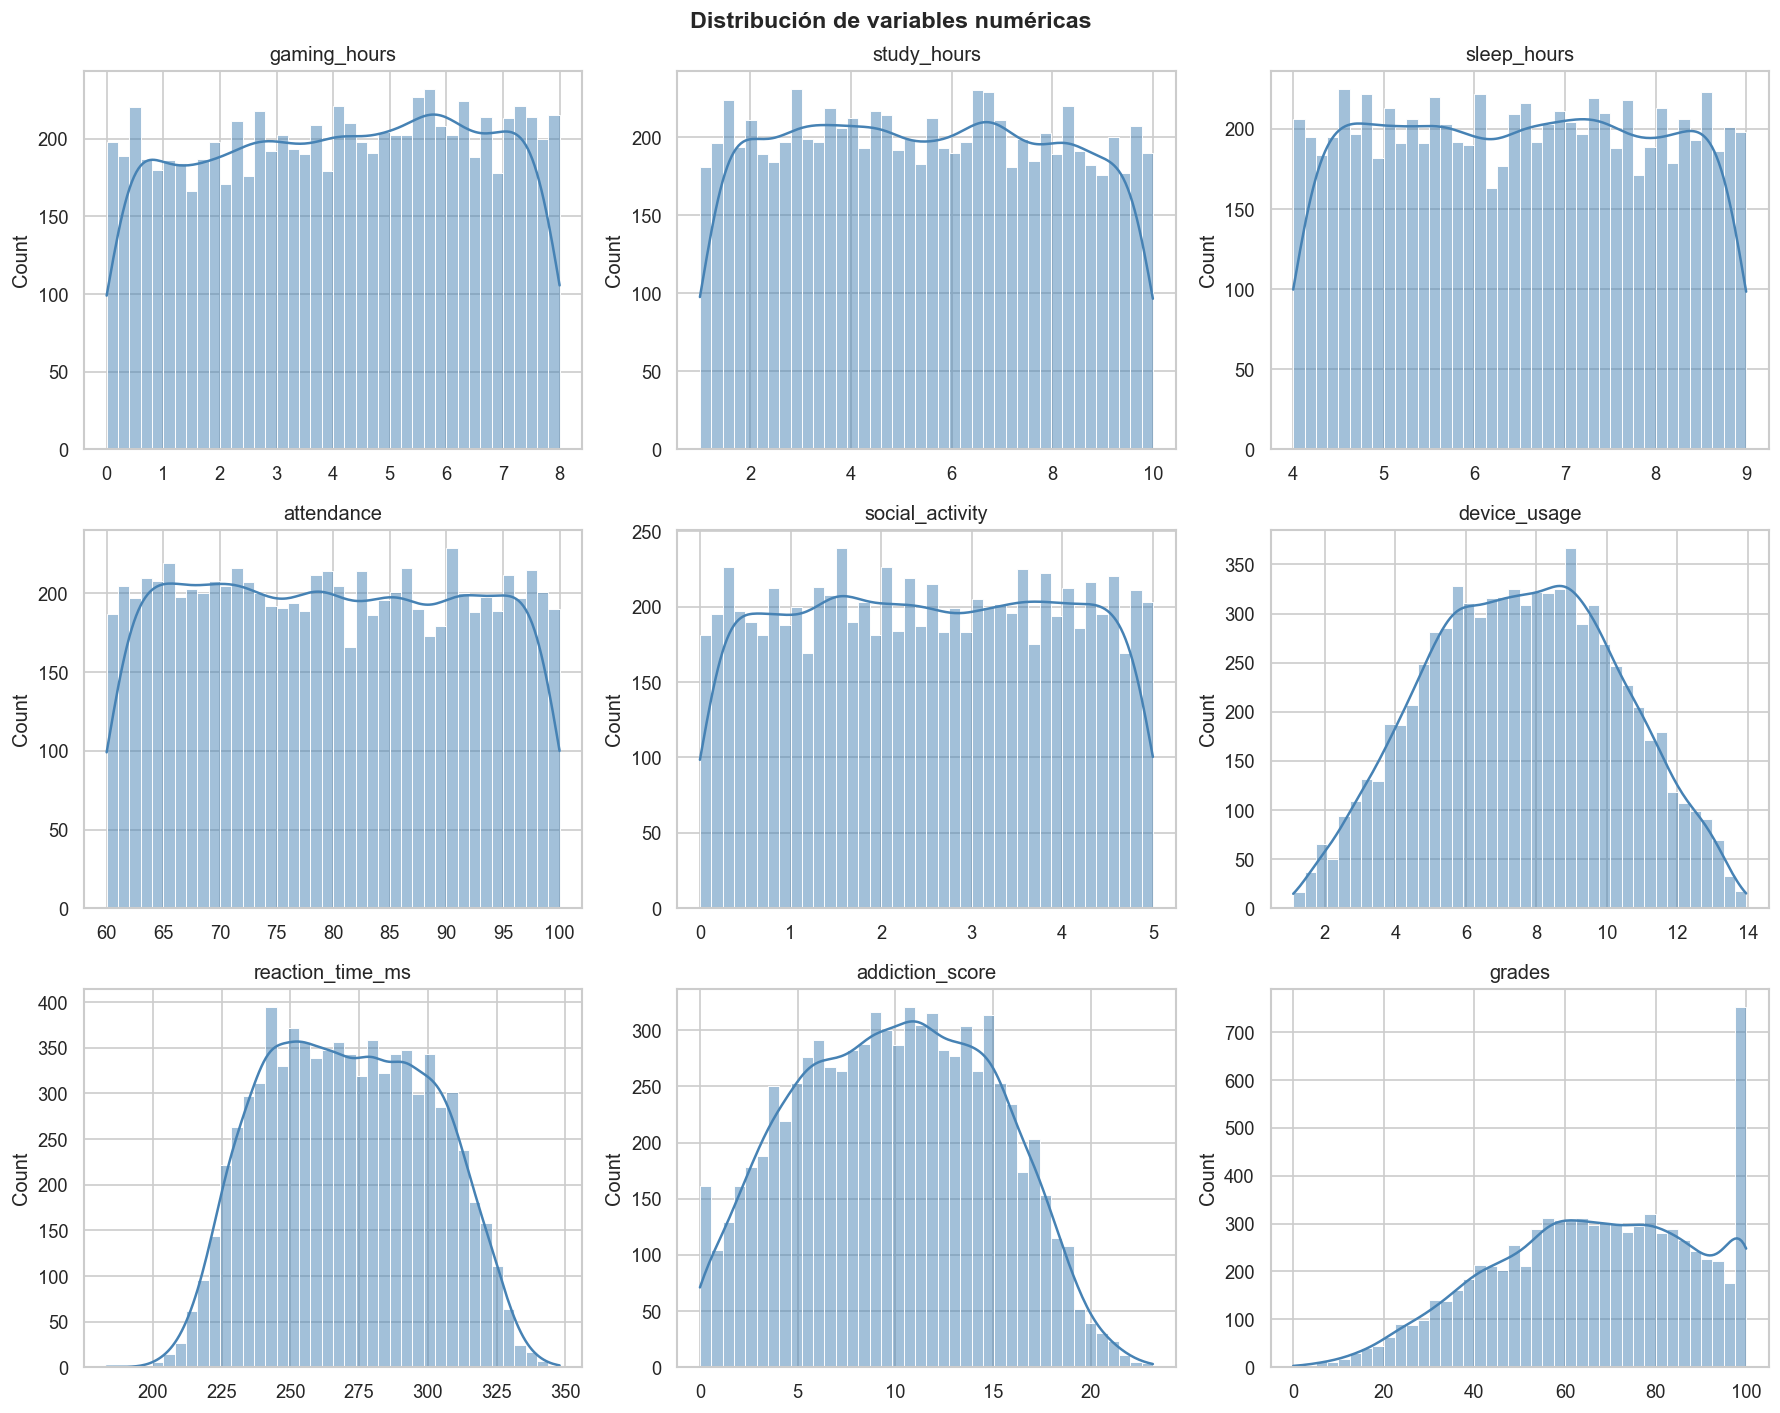

In [6]:
# Escogemos las variables númericas para el análisis.
num_cols = ['gaming_hours', 'study_hours', 'sleep_hours', 'attendance',
            'social_activity', 'device_usage', 'reaction_time_ms', 
            'addiction_score', 'grades']

# Configuramos el gráfico para mostrar las distribuciones.
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
fig.suptitle('Distribución de variables numéricas', fontsize=14, fontweight='bold')

# Iteramos sobre las variables y ejes para crear histogramas.
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')

# Guardar y mostrar el gráfico.
plt.tight_layout()
plt.savefig('./img/fig_distribuciones_numericas.png', dpi=120, bbox_inches='tight')
plt.show()


La mayoría son distribuciones normales (o Gaussianas) a excepción de addiction score, que está sesgada a la derecha, y grades, que se encuentra sesgada a la izquierda.

Son datos interesantes ya que 'addiction_score' muestran que los valores más altos son muy poco comunes. Al contrario que en 'grades', que las puntuaciones más bajas no están.

Continuamos con la distribución de la variable target (grades), ya que es la más importante del proyecto.

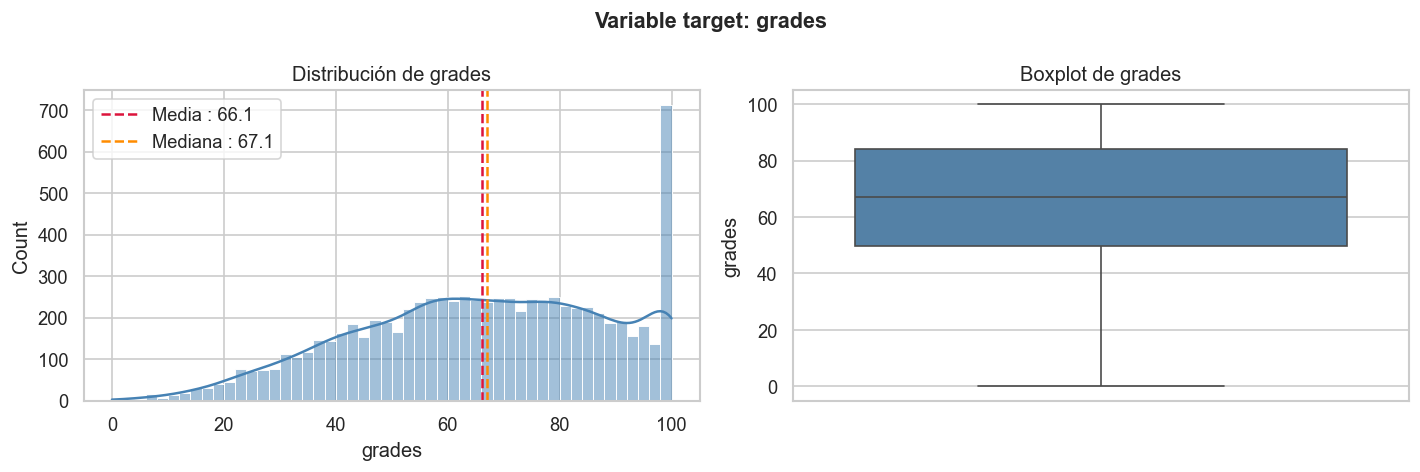

Media   : 66.08
Mediana : 67.07
Std     : 22.25
Skewness: -0.283


In [7]:
# Configuración del gráfico.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
fig.suptitle('Variable target: grades', fontsize=13, fontweight='bold')

# Histograma con KDE.
sns.histplot(df['grades'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(df['grades'].mean(), color='crimson', linestyle='--', linewidth=1.5, label=f'Media : {df["grades"].mean():.1f}')
axes[0].axvline(df['grades'].median(), color='darkorange', linestyle='--', linewidth=1.5, label=f'Mediana : {df["grades"].median():.1f}')
axes[0].set_title('Distribución de grades')
axes[0].legend()

# Boxplot. 
sns.boxplot(y=df['grades'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot de grades')

# Guardar y mostrar el gráfico.
plt.tight_layout()
plt.savefig('./img/fig_target_grades.png', dpi=120, bbox_inches='tight')
plt.show()

# Mostramos estadísticas.
print(f'Media   : {df["grades"].mean():.2f}')
print(f'Mediana : {df["grades"].median():.2f}')
print(f'Std     : {df["grades"].std():.2f}')
print(f'Skewness: {df["grades"].skew():.3f}')

La mediana y la media se encuentran muy cercana, lo que indica que la distribución es muy simétrica. Skewness es cercano a 0, lo que confirma la simetría.

Por otro lado, el boxplot muetra que no hay outliers.

Continuamos con la distribución de las variables categóricas.

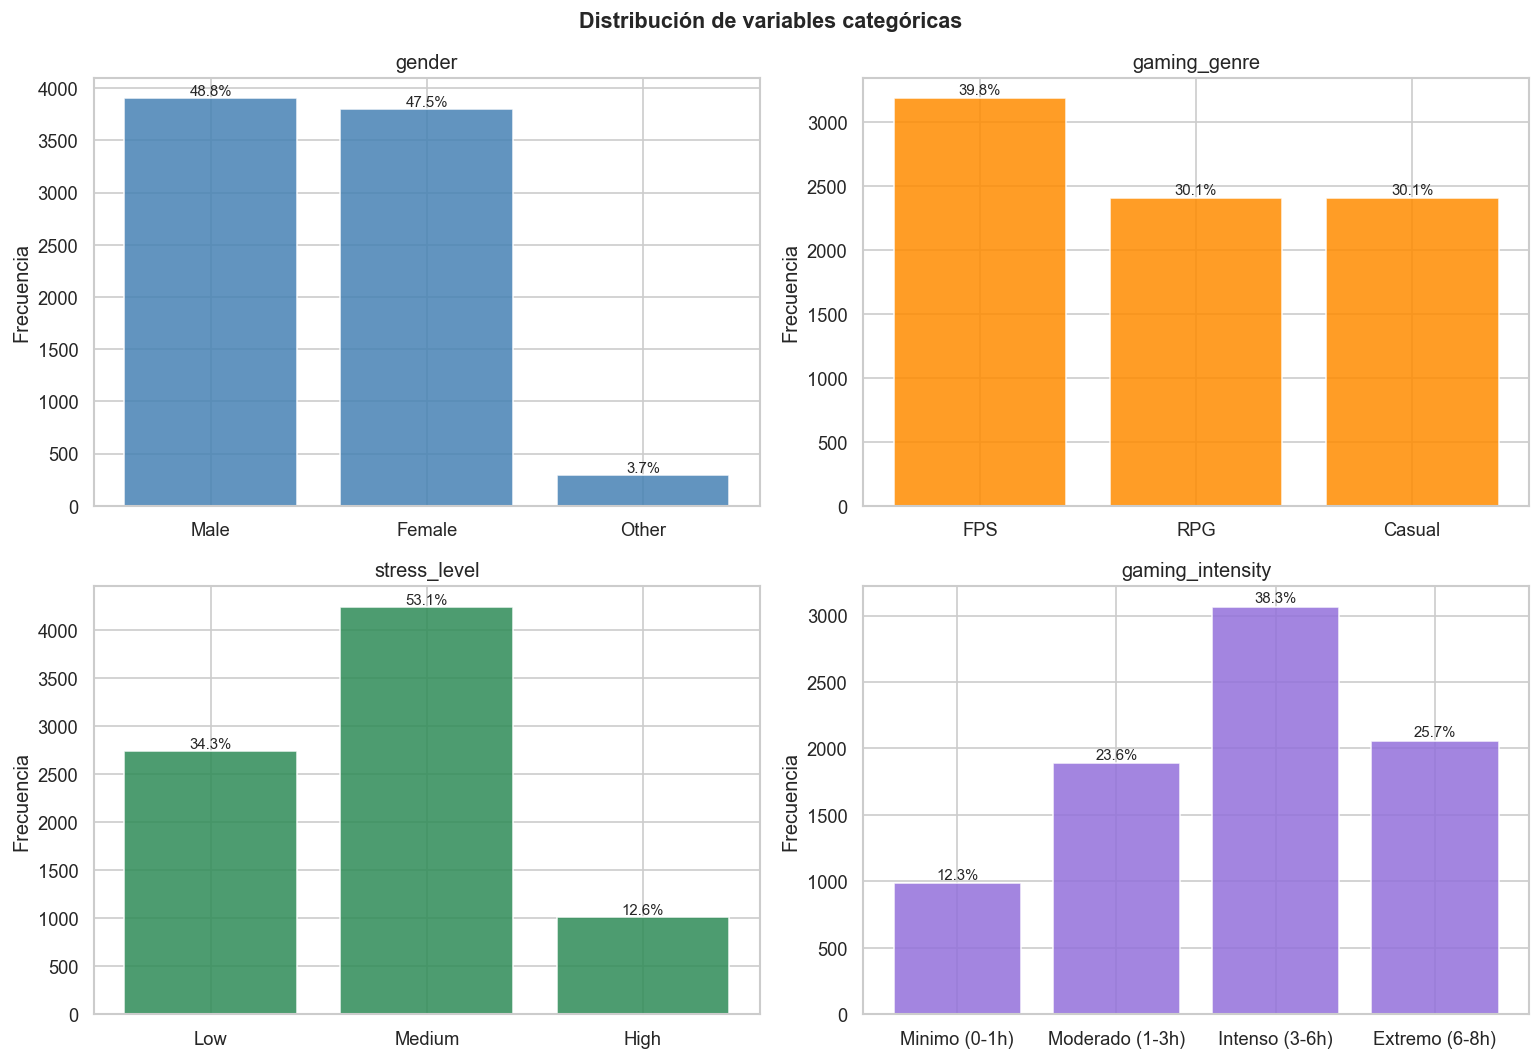

In [8]:
# Escogemos las variables categóricas para el análisis.
cat_cols = ['gender', 'gaming_genre', 'stress_level', 'gaming_intensity']

# Configuración del gráfico.
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(13, 9))
fig.suptitle('Distribución de variables categóricas', fontsize=13, fontweight='bold')

colores = ['steelblue', 'darkorange', 'seagreen', 'mediumpurple']

for ax, col, color in zip(axes.flatten(), cat_cols, colores):
    orden = df[col].cat.categories if hasattr(df[col], 'cat') else df[col].value_counts().index
    conteo = df[col].value_counts().reindex(orden)
    ax.bar(conteo.index.astype(str), conteo.values, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Frecuencia')
    for i, v in enumerate(conteo.values):
        ax.text(i, v + 30, f'{v/len(df)*100:.1f}%', ha='center', fontsize=9)

# Guardar y mostrar el gráfico.
plt.tight_layout()
plt.savefig('./img/fig_distribuciones_categoricas.png', dpi=120, bbox_inches='tight')
plt.show()

Vemos que las distribuciones de los géneros son muy equitativas. En cuanto al tipo de juego, vemos que hay dos tipos prácticamente iguales, y uno con un porcentaje algo superior, pero bastante balanceado. 

El stress level es quizás el más preocupante, ya que es la clase minoritaria con bastante diferencia de la segunda. 

Gaming intensity es parecido, pero al dividirse en 4 categorías puede aprender un poco mejor.

La última parte de esta sección será estudiar la proporción de estudiantes en riesgo.

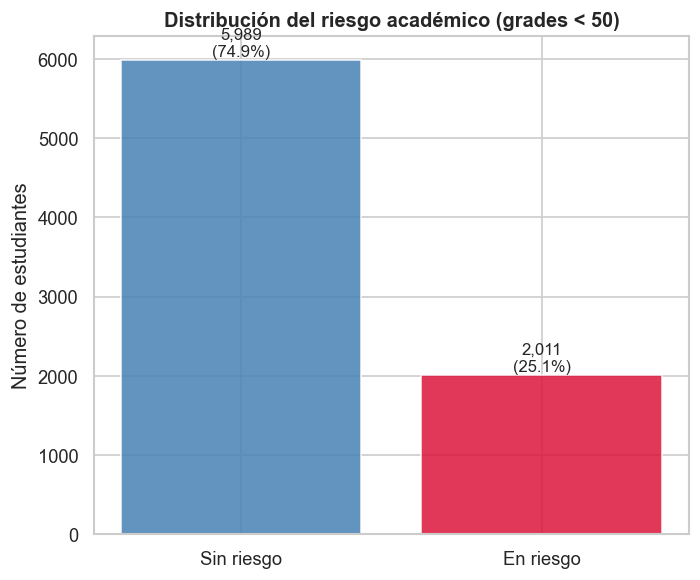

In [9]:
# Configuración del gráfico.
fig, ax = plt.subplots(figsize=(6,5))

colores_riesgo = ['steelblue','crimson']
etiquetas = ['Sin riesgo', 'En riesgo']
valores = df['risk_flag'].value_counts().sort_index()

bars = ax.bar(etiquetas, valores.values, color=colores_riesgo, alpha=0.85, edgecolor='white')

for bar, v in zip(bars, valores.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

ax.set_title('Distribución del riesgo académico (grades < 50)', fontweight='bold')
ax.set_ylabel('Número de estudiantes')

# Mostramos el gráfico.
plt.tight_layout()
plt.savefig('./img/fig_risk_flag.png', dpi=120, bbox_inches='tight')
plt.show()

Hay una distribución porcentual de 75/25 entre ellos, por lo que quizás deberíamos aplicar técnicas de balanceo.

## 3. Análisis bivariado

Cruzamos variables para encontrar patrones entre ellas.

Comenzamos con la correlación entre variables numéricas.

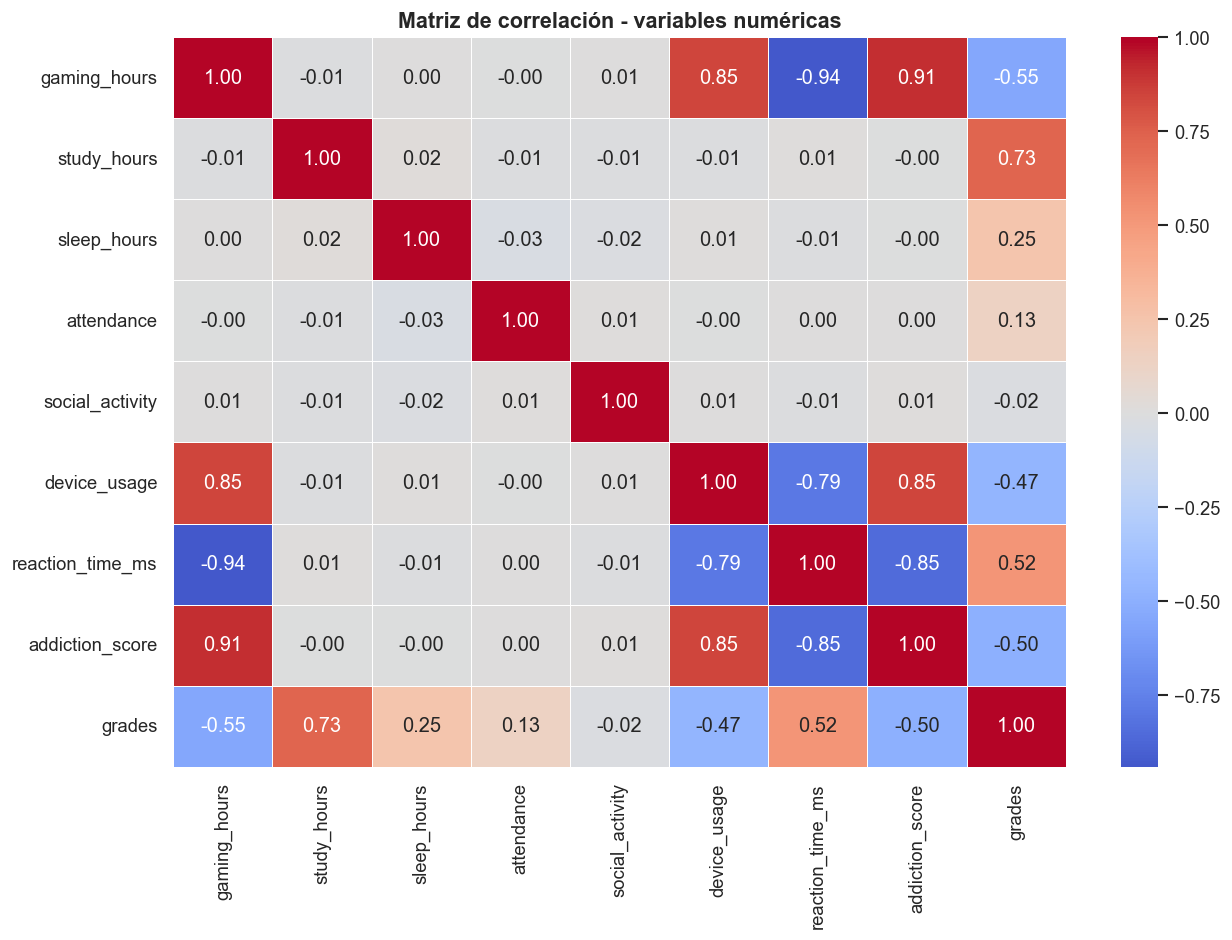

In [10]:
# Seleccionamos las variables numéricas que vamos a analizar.
num_cols = ['gaming_hours', 'study_hours', 'sleep_hours', 'attendance',
            'social_activity', 'device_usage', 'reaction_time_ms',
            'addiction_score', 'grades']

# Matriz de correlación.
corr_matrix = df[num_cols].corr()

# Configuración del gráfico.
fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5, center=0)
ax.set_title('Matriz de correlación - variables numéricas', fontsize=13, fontweight='bold')

# Guardar y mostrar el gráfico.
plt.tight_layout()
plt.savefig('./img/fig_matriz_correlacion.png', dpi=120, bbox_inches='tight')
plt.show()

Se pueden contemplar algunas correlaciones que tienen sentido, como puede ser la puntuación de adicción con las horas de gaming y el uso del dispositivo, o la correlación entre las horas de estudio y las puntuaciones finales. 

Por otro lado, es interesante ver como hay cierta relación entre el tiempo de reacción y las puntuaciones finales. 

Desde el punto de correlaciones negativas, se puede observar que el tiempo de reacción tiene altas correlaciones negativas con las horas de gaming, el uso de dispositivos y la adicción, llegando a la conclusión de que el tiempo de reacción mejora conforme crece la adicción.

El siguiente paso será comparar la relación entre las horas de gaming y las puntuaciones.

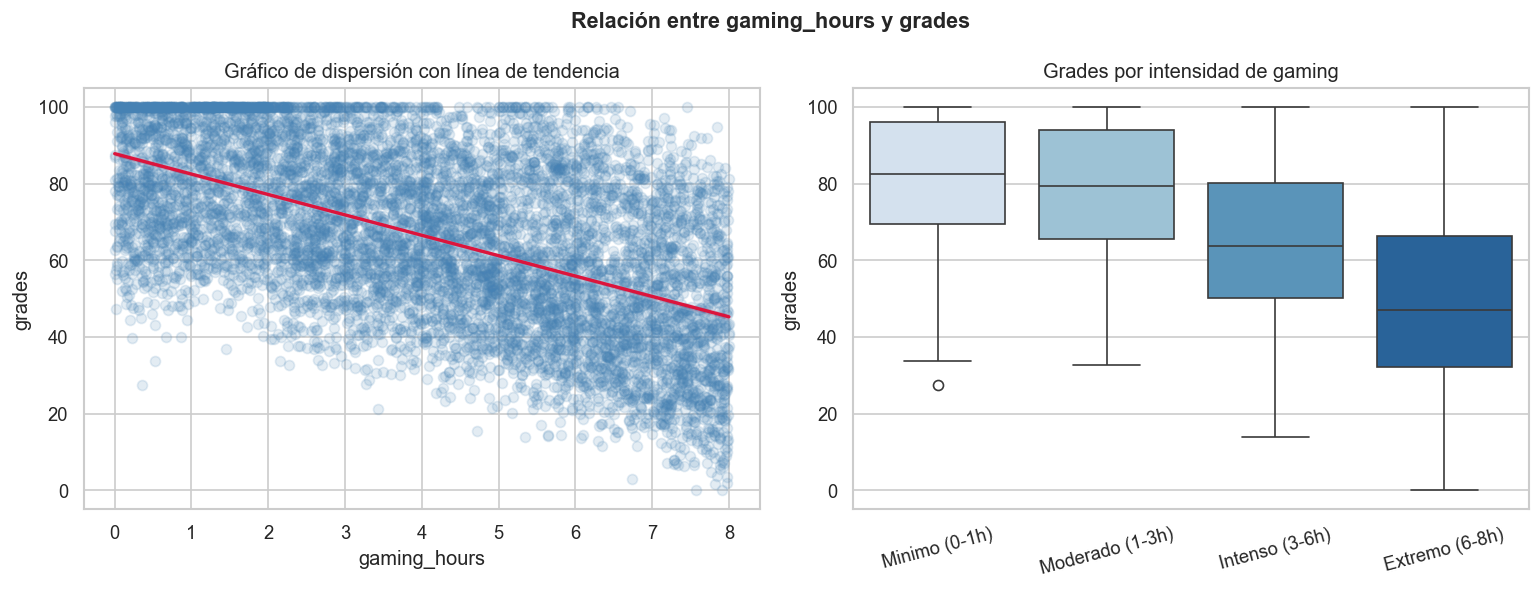

In [11]:
# Configuración del gráfico.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13,5))
fig.suptitle('Relación entre gaming_hours y grades', fontsize=13, fontweight='bold')

# Scatterplot con línea de tendencia.
sns.regplot(data=df, x='gaming_hours', y='grades', ax=axes[0], scatter_kws={'alpha':0.15, 'color':'steelblue'}, line_kws={'color':'crimson', 'linewidth':2})
axes[0].set_title('Gráfico de dispersión con línea de tendencia')

# Boxplot con gaming_intensity.
sns.boxplot(data=df, x='gaming_intensity', y='grades', ax=axes[1], palette='Blues', order=df['gaming_intensity'].cat.categories)
axes[1].set_title('Grades por intensidad de gaming')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

# Mostrar graficos.
plt.tight_layout()
plt.savefig('./img/fig_gaming_hours_grades.png', dpi=120, bbox_inches='tight')
plt.show()

Estos dos gráficos confirman lo que esperabamos, con forme suben las horas de gaming, las notas comienzan a descender. Las agrupaciones por grupos de horas lo corroboran.

Repetiremos el proceso con las horas de estudio y las puntuaciones.

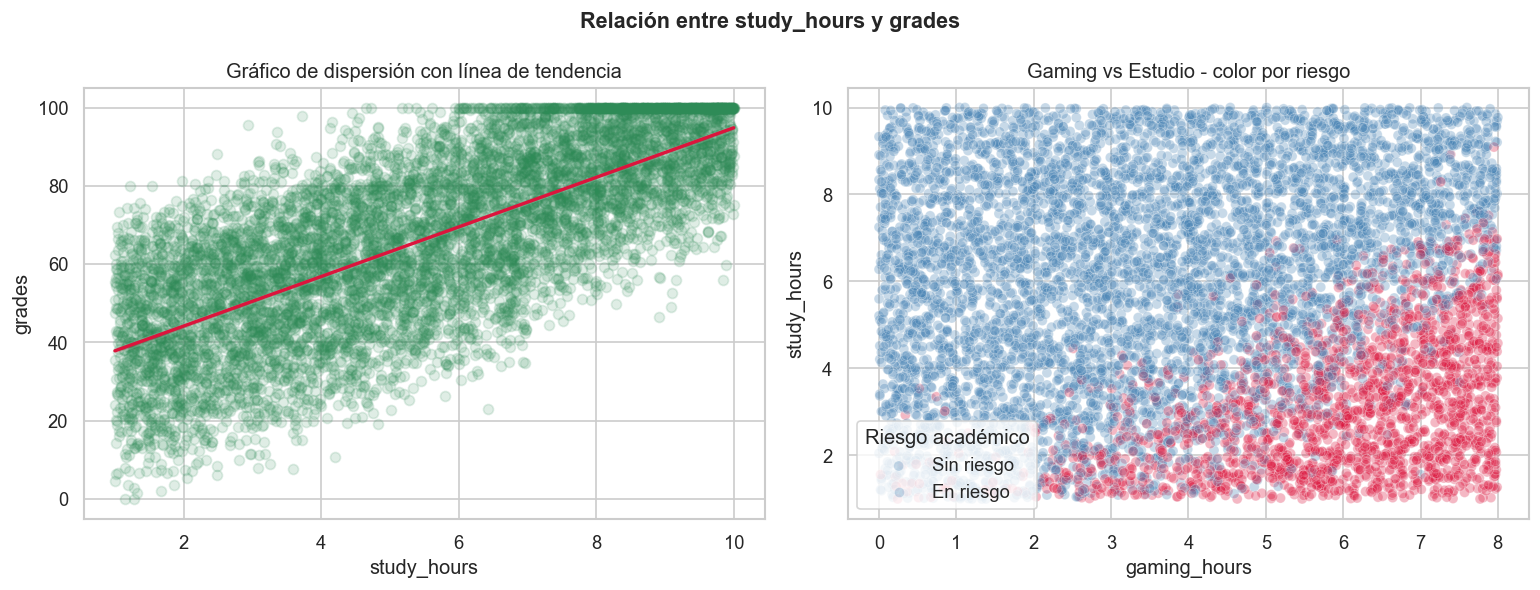

In [12]:
# Configuración del gráfico.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13, 5))
fig.suptitle('Relación entre study_hours y grades', fontsize=13, fontweight='bold')

# Gráfico de dispersión con línea de tendencia.
sns.regplot(data=df, x='study_hours', y='grades', ax=axes[0], scatter_kws={'alpha':0.15, 'color':'seagreen'}, line_kws={'color':'crimson', 'linewidth':2})
axes[0].set_title('Gráfico de dispersión con línea de tendencia')

# Comparativa de horas de gaming vs estudio.
sns.scatterplot(data=df, x='gaming_hours', y='study_hours', hue='risk_flag',ax=axes[1], alpha=0.3, palette={0:'steelblue', 1:'crimson'})
axes[1].set_title('Gaming vs Estudio - color por riesgo')
axes[1].legend(title='Riesgo académico', labels=['Sin riesgo', 'En riesgo'])

# Mostrar graficos.
plt.tight_layout()
plt.savefig('./img/fig_study_hours_grades.png', dpi=120, bbox_inches='tight')
plt.show()

En el gráfico de la derecha se puede observar que la mayoría de alumnos en riesgo tienen muchas horas de gaming y pocas de estudio (esquina inferior derecha). El gráfico de la izquierda confirma la gran correlación entre las horas de estudio y las puntuaciones.

Ahora se observarán la relación entre las variables de comportamiento del alumno con las notas finales.

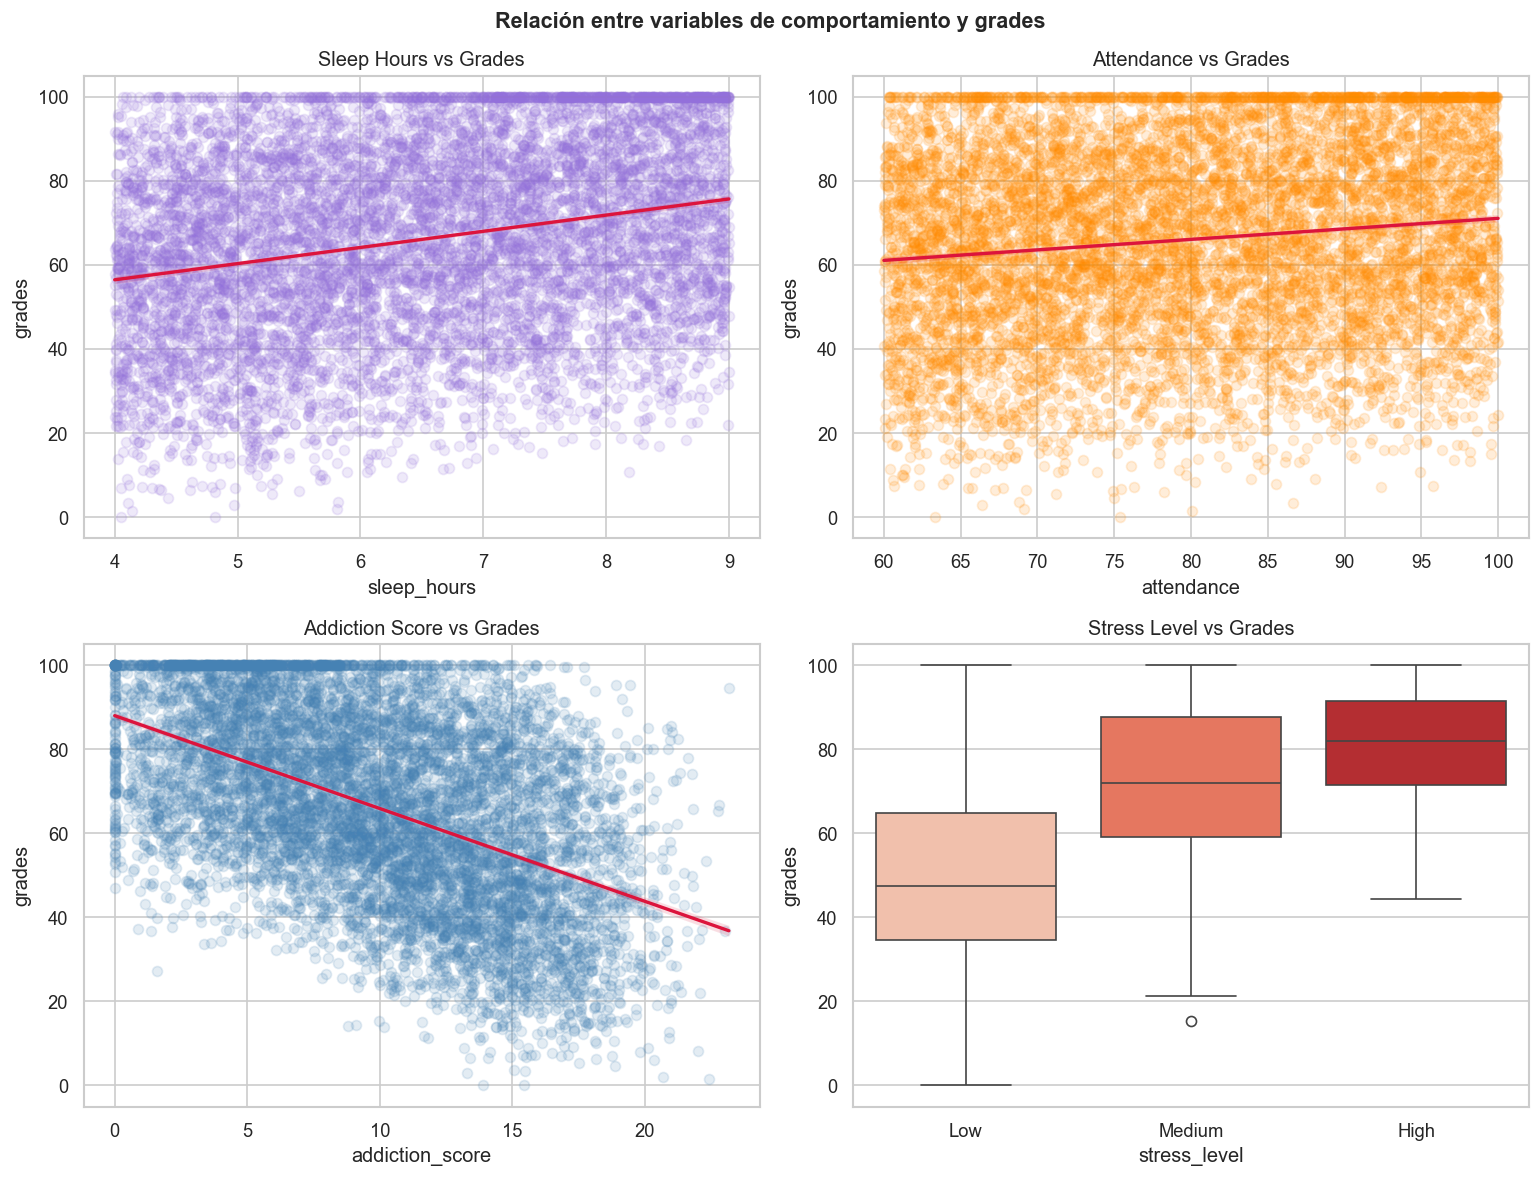

In [13]:
# Selección de variables.
vars_comportamiento = ['sleep_hours', 'attendance',' addiction_score', 'stress_level']

# Configuración del gráfico.
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(13, 10))
fig.suptitle('Relación entre variables de comportamiento y grades', fontsize=13, fontweight='bold')

# Gráfico de dispersión de las horas de sueño.
sns.regplot(data=df, x='sleep_hours', y='grades', ax=axes[0,0], scatter_kws={'alpha':0.15, 'color':'mediumpurple'}, line_kws={'color':'crimson', 'linewidth':2})
axes[0,0].set_title('Sleep Hours vs Grades')

# Grafico de dispersión de la asistencia a clase.
sns.regplot(data=df, x='attendance', y='grades', ax=axes[0,1], scatter_kws={'alpha':0.15, 'color':'darkorange'}, line_kws={'color':'crimson', 'linewidth':2})
axes[0,1].set_title('Attendance vs Grades')

# Gráfico de dispersión del addiction_score.
sns.regplot(data=df, x='addiction_score', y='grades', ax=axes[1,0], scatter_kws={'alpha':0.15, 'color':'steelblue'}, line_kws={'color':'crimson', 'linewidth':2})
axes[1,0].set_title('Addiction Score vs Grades')

# Boxplot del stress_level. (Es ordinal)
sns.boxplot(data=df, x='stress_level', y='grades', ax=axes[1,1], palette='Reds', order=['Low', 'Medium', 'High'])
axes[1,1].set_title('Stress Level vs Grades')

# Mostrar graficos.
plt.tight_layout()
plt.savefig('./img/fig_comportamiento_grades.png', dpi=120, bbox_inches='tight')
plt.show()

De estos distintos gráficos se pueden sacar varias conclusiones:

1º Las notas tienden a ser más altas cuantas más horas de sueño se dan, o cuanto más se aproximan al horario de sueño recomendado. Esto puede deberse a varios factores, pero mi teoría es que puede ser que los alumnos sacrifiquen horas de sueño para estudiar y dediquen el resto de horas para entretenimiento. 

2º Parece que la asistencia a clase no tiene gran relevancia en las notas. Esto puede indicar que las clases tienen poca utilidad, siendo más importante el estudio.

3º De forma más clara, los alumnos con más puntuación de adicción tienen peores notas. 

4º Los alumnos obtienen mejores notas cuanto más nivel de estrés tienen. Existen varias razones, pero mi hipótesis es que el estrés proviene de las horas de estudio y de la importancia que se le da a los estudios. Con esto quiero decir, que al estudiar más se obtienen mejores notas, pero también genera un mayor nivel de estrés. 
    

## 4. Análisis por grupos

Analizaremos distribuciones de distintos grupos de características distintos.

Comenzaremos por el rendimiento acádemico basado en el género.

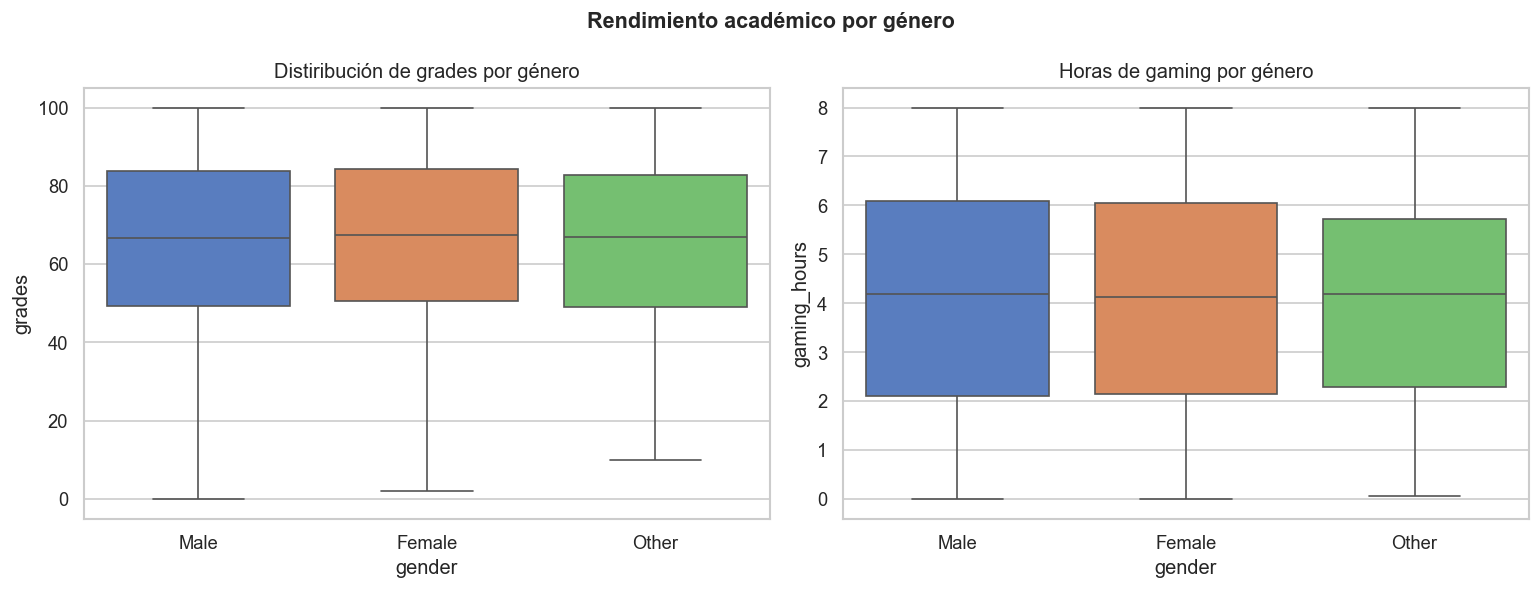

        grades  gaming_hours
gender                      
Female   66.46          4.09
Male     65.77          4.08
Other    65.25          4.02


In [14]:
# Configuración del gráfico.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13, 5))
fig.suptitle('Rendimiento académico por género', fontsize=13, fontweight='bold')

# Boxplot de grades por género.
sns.boxplot(data=df, x='gender', y='grades', ax=axes[0], palette='muted', order=['Male','Female','Other'])
axes[0].set_title('Distiribución de grades por género')

# Horas de gaming por género.
sns.boxplot(data=df, x='gender', y='gaming_hours', ax=axes[1], palette='muted', order=['Male','Female','Other'])
axes[1].set_title('Horas de gaming por género')

# Mostrar graficos.
plt.tight_layout()
plt.savefig('./img/fig_genero_rendimiento.png', dpi=120, bbox_inches='tight')
plt.show()

# Estadísticas por grupo.
print(df.groupby('gender')[['grades','gaming_hours']].mean().round(2))

La conclusión obtenida de estos gráficos no tiene prácticamente impacto en las notas ni en las horas de gaming. 

Ahora analizaremos los distintos géneros de videojuegos.

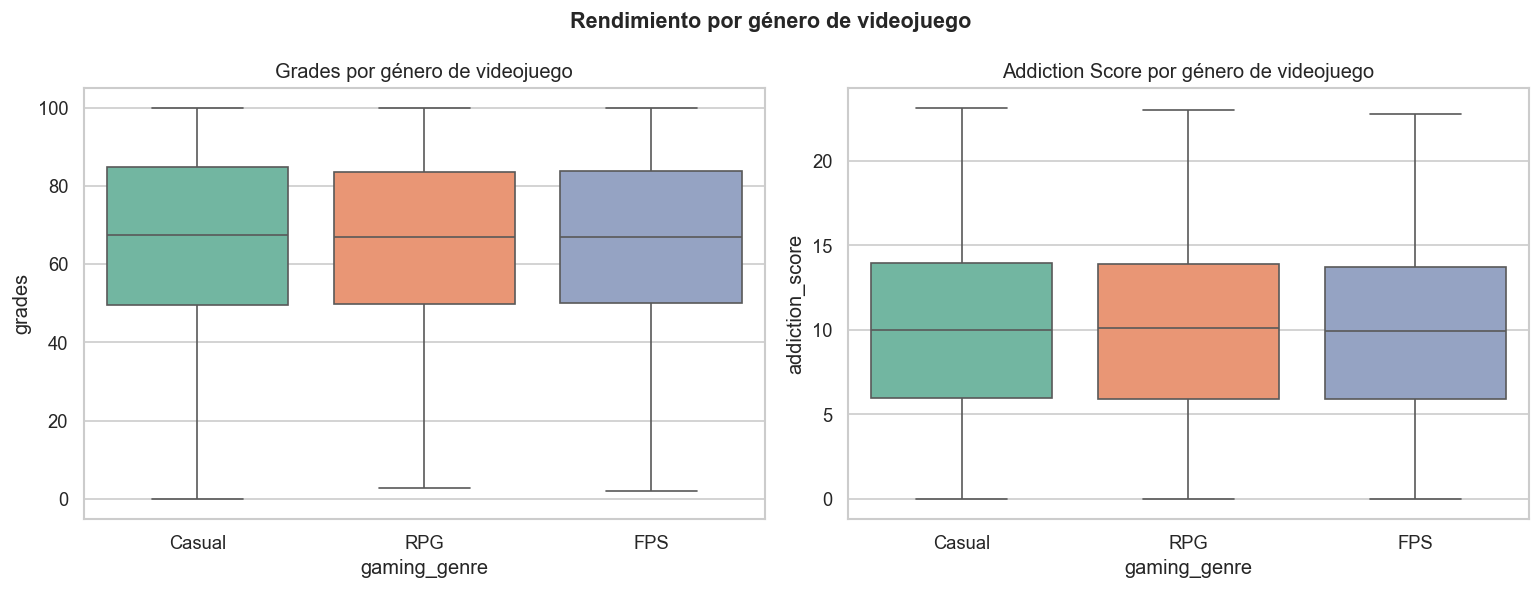

              grades  addiction_score
gaming_genre                         
Casual         66.30            10.00
FPS            66.07             9.83
RPG            65.88             9.96


In [15]:
# Configuración del gráfico.
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13,5))
fig.suptitle('Rendimiento por género de videojuego', fontsize=13, fontweight='bold')

# Boxplot de grades por género de videojuego.
sns.boxplot(data=df, x='gaming_genre', y='grades', ax=axes[0], palette='Set2', order=['Casual','RPG','FPS'])
axes[0].set_title('Grades por género de videojuego')

# Boxplot de addiction_score por género de videojuego.
sns.boxplot(data=df, x='gaming_genre', y='addiction_score', ax=axes[1], palette='Set2', order=['Casual','RPG','FPS'])
axes[1].set_title('Addiction Score por género de videojuego')

# Mostrar graficos.
plt.tight_layout()
plt.savefig('./img/fig_genero_videojuego.png', dpi=120, bbox_inches='tight')
plt.show()

# Estadísticas por grupo.
print(df.groupby('gaming_genre')[['grades','addiction_score']].mean().round(2))

Al igual que con el género, el género del videojuego no tiene impacto en las notas o en las adicciones.

Ahora, vamos a investigar los distintos perfiles del estudiante, el que se encuentra en riesgo o sin riesgo.

In [16]:
# Seleccionamos las categorías a analizar.
categorias = ['gaming_hours', 'study_hours', 'sleep_hours','attendance', 'addiction_score', 'reaction_time_ms']

# Agrupamos por riesgo académico.
perfil = df.groupby('risk_flag')[categorias].mean().round(2)
perfil.index = ['Sin riesgo', 'En riesgo']
print(perfil.T)

                  Sin riesgo  En riesgo
gaming_hours            3.47       5.93
study_hours             6.24       3.15
sleep_hours             6.64       6.06
attendance             80.49      78.08
addiction_score         8.72      13.51
reaction_time_ms      278.48     249.14


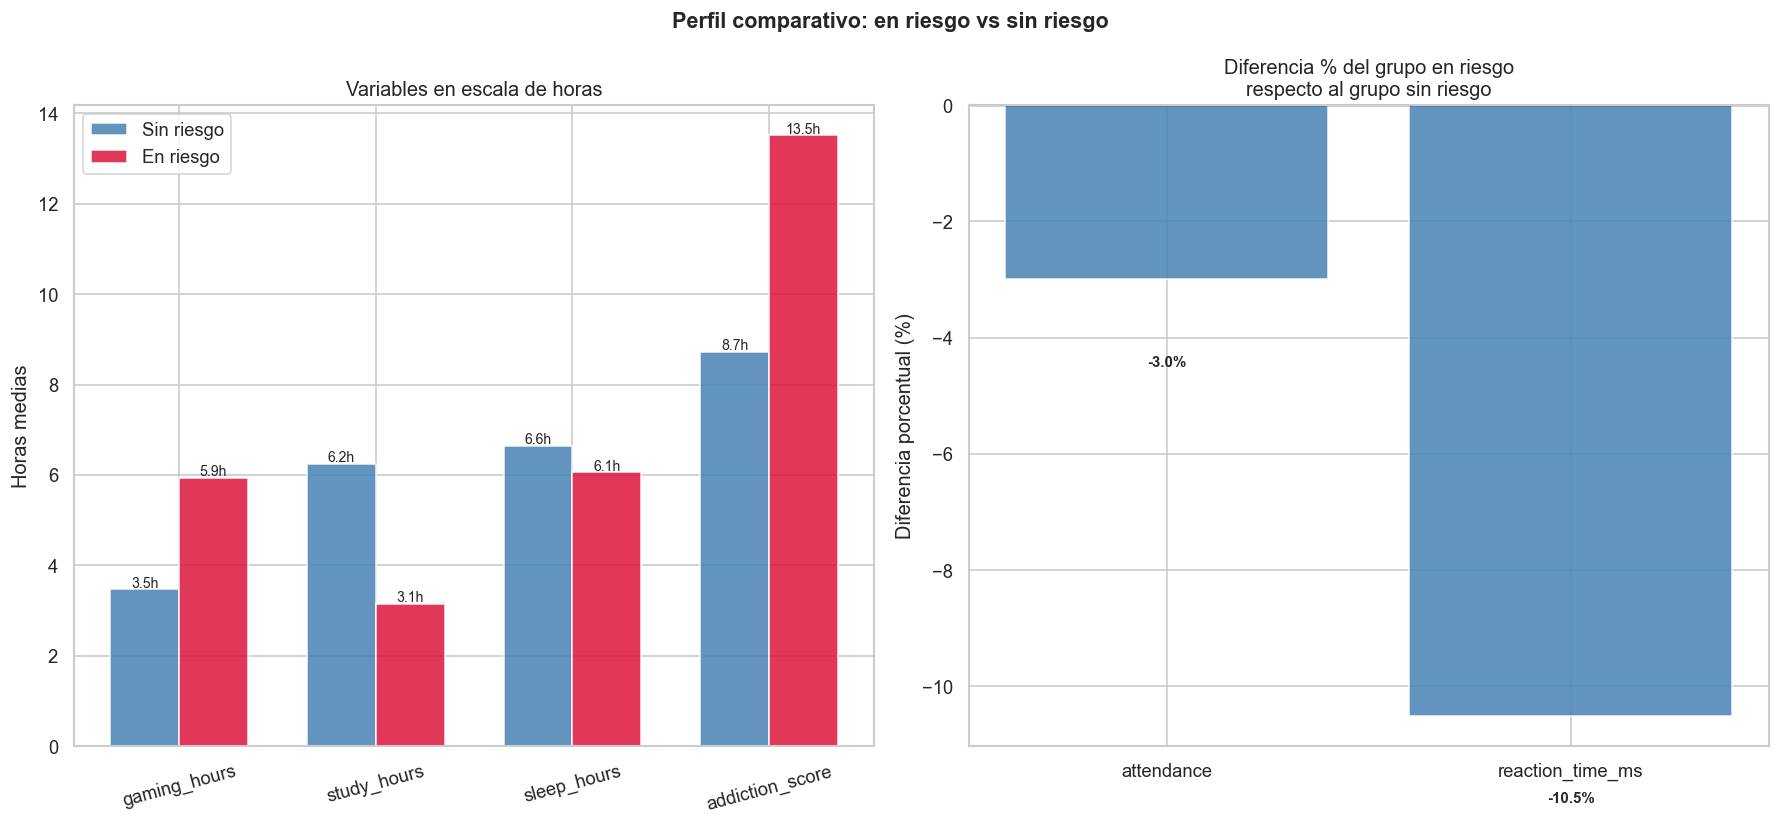

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Perfil comparativo: en riesgo vs sin riesgo', 
             fontsize=13, fontweight='bold')

# ── Subplot izquierdo: variables en escala de horas ──
vars_horas = ['gaming_hours', 'study_hours', 'sleep_hours','addiction_score']
perfil_horas = perfil[vars_horas]

x = np.arange(len(vars_horas))
width = 0.35

b1 = axes[0].bar(x - width/2, perfil_horas.loc['Sin riesgo'], width,
                  label='Sin riesgo', color='steelblue', alpha=0.85)
b2 = axes[0].bar(x + width/2, perfil_horas.loc['En riesgo'], width,
                  label='En riesgo', color='crimson', alpha=0.85)

for bar in b1:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f'{bar.get_height():.1f}h', ha='center', fontsize=8.5)
for bar in b2:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f'{bar.get_height():.1f}h', ha='center', fontsize=8.5)

axes[0].set_xticks(x)
axes[0].set_xticklabels(vars_horas, rotation=15)
axes[0].set_title('Variables en escala de horas')
axes[0].set_ylabel('Horas medias')
axes[0].legend()

# ── Subplot derecho: diferencia porcentual respecto al grupo sin riesgo ──
vars_escala_mixta = ['attendance','reaction_time_ms']

diff_pct = ((perfil.loc['En riesgo', vars_escala_mixta] - 
             perfil.loc['Sin riesgo', vars_escala_mixta]) / 
             perfil.loc['Sin riesgo', vars_escala_mixta] * 100).round(1)

colores_diff = ['crimson' if v > 0 else 'steelblue' for v in diff_pct.values]

bars = axes[1].bar(vars_escala_mixta, diff_pct.values, 
                    color=colores_diff, alpha=0.85, edgecolor='white')

for bar, v in zip(bars, diff_pct.values):
    offset = 0.5 if v >= 0 else -1.5
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + offset,
                 f'{v:+.1f}%', ha='center', fontsize=9, fontweight='bold')

axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Diferencia % del grupo en riesgo\nrespecto al grupo sin riesgo')
axes[1].set_ylabel('Diferencia porcentual (%)')

plt.tight_layout()
plt.savefig('./img/fig_perfil_riesgo.png', dpi=120, bbox_inches='tight')
plt.show()

El gráfico de la derecha muestra que los estudiantes en riesgo asisten un 3% menos a clase que los que no están en riesgo. Tiene sentido que una menor asistencia se asocie a un peor rendimiento, aunque no tiene tanta importancia. 

Por otro lado, muestra que los estudiantes en riesgo tienen un tiempo de reacción un 10,5% menor que los que no están en riesgo. Los milisegundos, cuanto más bajos indica mayor tiempo de reacción. Esto explica lo mostrado en el mapa de calor, los estuantes que juegan más horas reaccionan más rápido pero genera un impacto negativo en las notas.

El gráfico de la izquierda muestra datos más obvios: los estudiantes que más horas de gaming emplean, que estudian menos, que tienen más adicción, son los que se encuentran en riesgo.